In [1]:
import math
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sumolib
import contextily as cx
import geopandas 
import lib.dataGenLib as dg
import json
import rtree

In [2]:
%load_ext autoreload
%autoreload 2

# SITE 10
# Concatenate all CSV data

In [3]:
dataset_site10_path = './dataset10/rawdata/'
csv_files = dg.retrieve_csv_files(dataset_site10_path)
csv_files[:2], len(csv_files)

(['tracking_list1607209928.csv', 'tracking_list1607216068.csv'], 68)

In [4]:
df = dg.read_all_csv(csv_files,dataset_site10_path)
df.head(2), df.shape

(        Id      timestamp  positionX  positionY  positionZ     sizeX  \
 0  7178720  1607209927867 -79.759659 -36.794369  -0.441839  5.656100   
 1  7192515  1607209927867  66.916222  75.193825   2.891212  1.389838   
 
       sizeY     sizeZ      VelX      VelY      VelZ       Vel    Class  
 0  0.154723  0.159434  0.015397  0.002812 -0.003002  0.057374  UNKNOWN  
 1  0.563836  6.567886 -0.048418 -0.089765 -0.659526  2.402516  UNKNOWN  ,
 (27220761, 13))

In [5]:
df['timestamp'].astype('datetime64[ms]').max(),df['timestamp'].astype('datetime64[ms]').min()

(Timestamp('2020-12-12 23:30:42.917000'),
 Timestamp('2020-12-05 23:12:07.867000'))

# Find all '__Vehicle__' class dataset

In [6]:
# Filter vehicle class by frequency
vehicle_list = dg.filtrate_object(df)
df_v = dg.select_by_id(df,vehicle_list)

In [7]:
# Select vehicle trajectory by appearance lifetime
v_list, low_list, up_list = dg.data_select_period(df_v, start=100.,stop=150.)
l_v_df = dg.select_by_id(df_v,v_list)
l_low_df = dg.select_by_id(df_v,low_list)
l_up_df = dg.select_by_id(df_v,up_list)

In [8]:
# load sumo net xml
net = sumolib.net.readNet("./dataset10/map/site10_new.net.xml")

In [9]:
# get sumo Geo projection reference
p = net.getGeoProj()
p.crs 

<Projected CRS: +proj=utm +zone=31 +ellps=WGS84 +datum=WGS84 +unit ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# get sumo information
lat,lon,head = dg.rsu_info("rsu10.json")

# get rsu projected geoposition 
x, y = p(lon,lat)

In [11]:
# rotation matrix, To convert the trajectory geoposition
theta = math.radians(head)
rotation = np.matrix([[np.sin(theta),np.cos(theta)],
                      [np.cos(theta),-np.sin(theta)]])
rotation

matrix([[-0.82903757, -0.5591929 ],
        [-0.5591929 ,  0.82903757]])

In [12]:
rot_v_df = dg.rot_data(l_v_df,head)# x, y = net.convertLonLat2XY(lon,lat)
rot_low_df = rotation.dot(np.array([l_low_df.loc[:,'positionX'],l_low_df.loc[:,'positionY']]))
rot_up_df = rotation.dot(np.array([l_up_df.loc[:,'positionX'],l_up_df.loc[:,'positionY']]))
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = np.array(rot_low_df[0,:]).flatten()+x
low_ry = np.array(rot_low_df[1,:]).flatten()+y

up_rx = np.array(rot_up_df[0,:]).flatten()+x
up_ry = np.array(rot_up_df[1,:]).flatten()+y

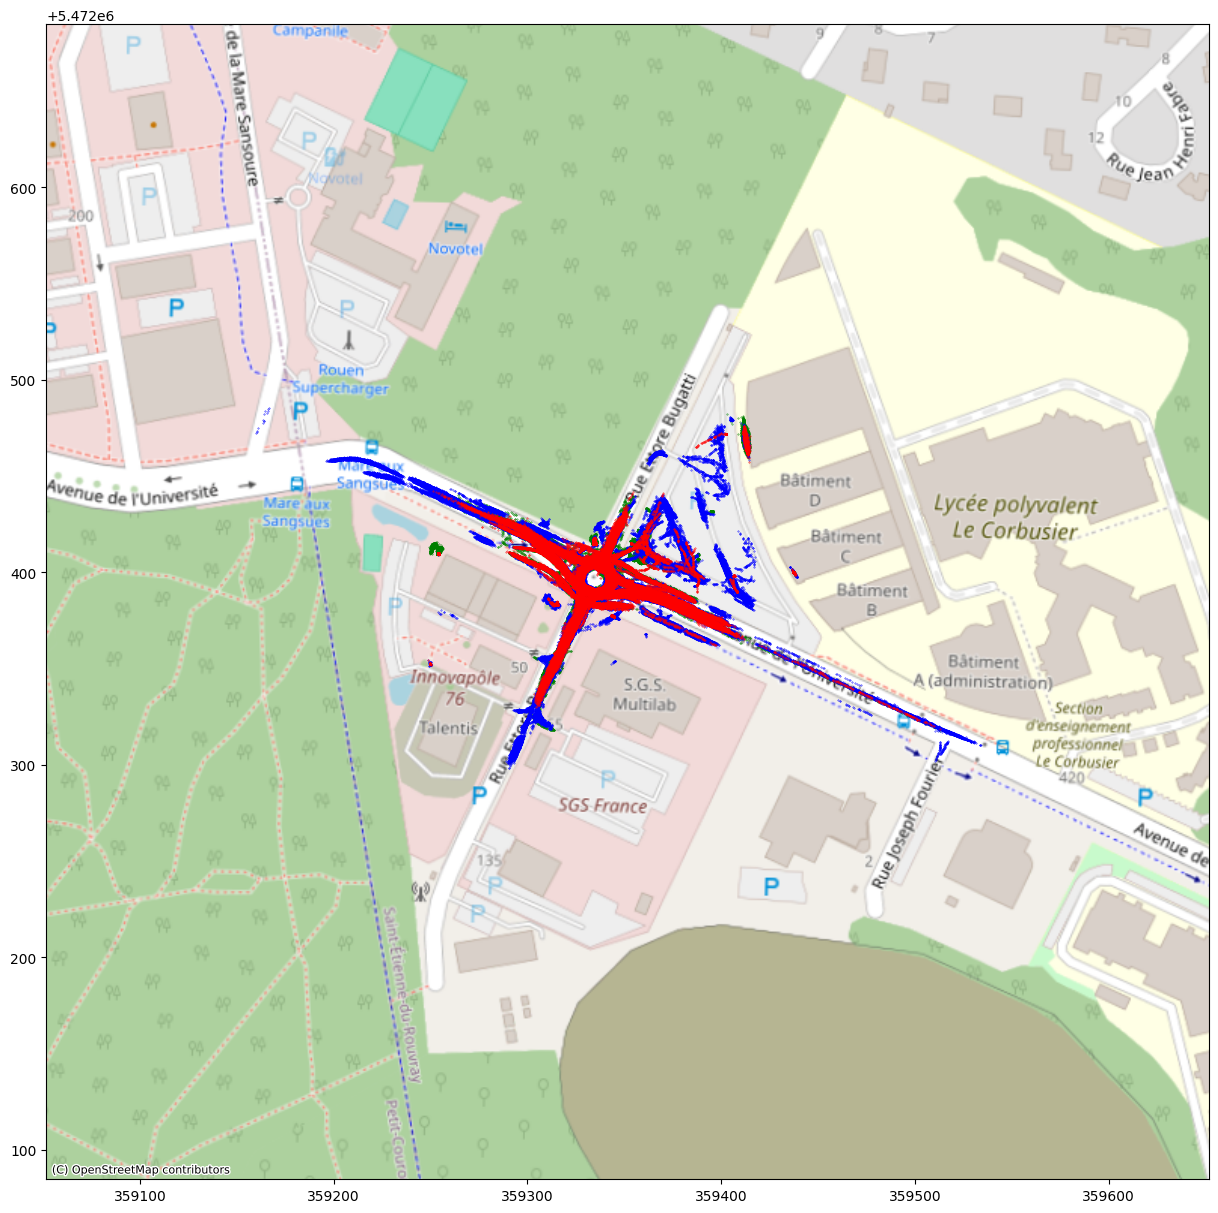

In [13]:
fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

# Filter data which is not on the selected road 

In [14]:
x, y = net.convertLonLat2XY(lon,lat)
rot_v_df = dg.rot_data(l_v_df,head)
rot_low_df = dg.rot_data(l_low_df,head)
rot_up_df = dg.rot_data(l_up_df,head)

v_rx = rot_v_df.loc[:,'rot_x']+x
v_ry = rot_v_df.loc[:,'rot_y']+y
# radius = 0.5
# edges = net.getNeighboringEdges(v_rx.iloc[0], v_ry.iloc[0], radius)
# # pick the closest edge
# if len(edges) > 0:
#     distancesAndEdges = sorted([(dist, edge) for edge, dist in edges], key=lambda x:x[0])
#     dist, closestEdge = distancesAndEdges[0]
    
# edges,dist,closestEdge.getID() , net.getEdge('60546306#1').getType()
row,_ = rot_v_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_v_df['edge'] = edge_list


v_rx = rot_low_df.loc[:,'rot_x']+x
v_ry = rot_low_df.loc[:,'rot_y']+y
row,_ = rot_low_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_low_df['edge'] = edge_list


v_rx = rot_up_df.loc[:,'rot_x']+x
v_ry = rot_up_df.loc[:,'rot_y']+y
row,_ = rot_up_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_up_df['edge'] = edge_list

In [15]:
rot_v_df = rot_v_df[rot_v_df['edge'].notnull()]
rot_low_df = rot_low_df[rot_low_df['edge'].notnull()]
rot_up_df = rot_up_df[rot_up_df['edge'].notnull()]

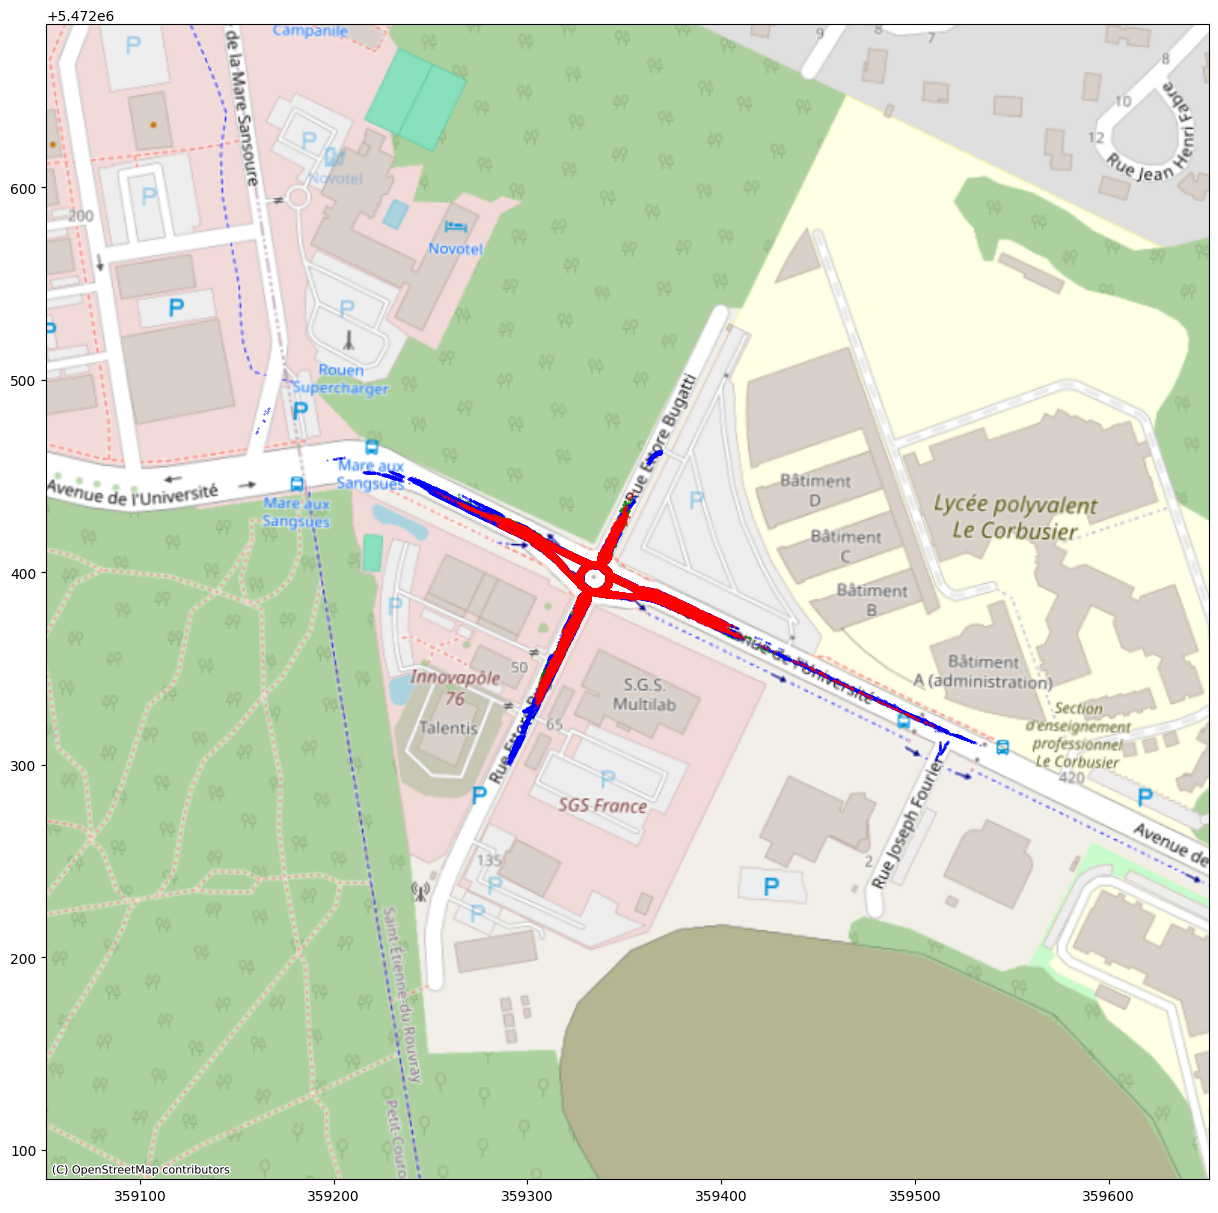

In [16]:
x, y = p(lon,lat)
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = rot_low_df.loc[:,"rot_x"]+x
low_ry = rot_low_df.loc[:,"rot_y"]+y

up_rx = rot_up_df.loc[:,"rot_x"]+x
up_ry = rot_up_df.loc[:,"rot_y"]+y

fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

# Save new training dataset with a fixed squence length

In [17]:
# interpolation for incomplete squences.
c_sq_df = dg.data_padding(rot_v_df,pad_method='linear',period_start=0,period_stop=-1)

In [18]:
# check if there are null values
c_sq_df[c_sq_df.isnull().any(axis=1)],c_sq_df.shape

(Empty DataFrame
 Columns: [Id, timestamp, positionX, positionY, positionZ, sizeX, sizeY, sizeZ, VelX, VelY, VelZ, Vel, Class, rot_x, rot_y, edge, ts]
 Index: [],
 (485784, 17))

In [19]:
c_sq_df = c_sq_df.dropna(how='all')
c_sq_df.shape

(485784, 17)

In [20]:
# add departure and destination 
df1 = c_sq_df.copy()
v_list = []
for k,v in c_sq_df.groupby(by=['Id']):
    v['departure'] = np.repeat(v.iloc[0,15],len(v))
    v['destination'] =  np.repeat(v.iloc[-1,15],len(v))
    v_list.append(v.copy())
new_c_sq_df = pd.concat(v_list)
new_c_sq_df.head(1)

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts,departure,destination
0,405,1607507768887.0,21.899197,49.760029,-5.164676,0.227956,1.198696,0.082061,-1.029024,-1.422561,0.281053,6.401079,UNKNOWN,-45.980712,29.007058,60546306#0,0,60546306#0,-172341587#1


In [21]:
# stride 5s
rolling_window_df_1 = dg.rolling_window(new_c_sq_df.copy(),stride=50)
rolling_window_df_1.shape

(418977, 20)

In [22]:
# stride 1s
rolling_window_df_2 = dg.rolling_window(new_c_sq_df.copy(),stride=10)
rolling_window_df_2.shape

(1875814, 20)

In [23]:
new_c_sq_df.shape

(485784, 19)

In [24]:
from datetime import datetime
now = datetime.now()
time = now.strftime("%Y%d%m_%H:%M:%S")

new_c_sq_df.to_csv('./dataset10/training/training_0_999_'+time+'.csv',index=False)
rolling_window_df_1.to_csv('./dataset10/training/training_0_999_r1_'+time+'.csv',index=False)
rolling_window_df_2.to_csv('./dataset10/training/training_0_999_r2_'+time+'.csv',index=False)

# SITE 1
# Concatenate all CSV data

In [25]:
dataset_site1_path = './dataset1/rawdata/'
csv_files = dg.retrieve_csv_files(dataset_site1_path)
csv_files[:2], len(csv_files)

(['tracking_list1607290364.csv', 'tracking_list1607327189.csv'], 650)

In [26]:
df = dg.read_all_csv(csv_files,dataset_site1_path)
df.head(2), df.shape

(         Id      timestamp   positionX   positionY  positionZ     sizeX  \
 0  11901192  1607290364861  -71.333778 -106.959785  -9.916469  2.522806   
 1  14486388  1607290364861 -112.848953   64.413406  -1.518354  4.364914   
 
       sizeY     sizeZ      VelX      VelY      VelZ       Vel    Class  
 0  0.133535  0.066734 -0.005376  0.009542  0.001049  0.039609  UNKNOWN  
 1  0.185796  0.124093  0.001267 -0.045038 -0.001720  0.162319  UNKNOWN  ,
 (28679927, 13))

In [27]:
df['timestamp'].astype('datetime64[ms]').max(),df['timestamp'].astype('datetime64[ms]').min()

(Timestamp('2021-06-23 22:45:07.447000'),
 Timestamp('2020-12-06 21:32:44.861000'))

# Find all '__Vehicle__' class dataset

In [28]:
# Filter vehicle class by frequency
vehicle_list = dg.filtrate_object(df)
df_v = dg.select_by_id(df,vehicle_list)

In [29]:
# Select vehicle trajectory by appearance lifetime
v_list, low_list, up_list = dg.data_select_period(df_v, start=100.,stop=150.)
l_v_df = dg.select_by_id(df_v,v_list)
l_low_df = dg.select_by_id(df_v,low_list)
l_up_df = dg.select_by_id(df_v,up_list)

In [30]:
# load sumo net xml
net = sumolib.net.readNet("./dataset1/map/site1_new.net.xml")

In [31]:
# get sumo Geo projection reference
p = net.getGeoProj()
p.crs 

<Projected CRS: +proj=utm +zone=31 +ellps=WGS84 +datum=WGS84 +unit ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [32]:
# get sumo information
lat,lon,head = dg.rsu_info("rsu1.json")

# get rsu projected geoposition 
x, y = p(lon,lat)

In [33]:
# rotation matrix, To convert the trajectory geoposition
theta = math.radians(head)
rotation = np.matrix([[np.sin(theta),np.cos(theta)],
                      [np.cos(theta),-np.sin(theta)]])
rotation

matrix([[ 0.95891882, -0.28368064],
        [-0.28368064, -0.95891882]])

In [34]:
rot_v_df = dg.rot_data(l_v_df,head)# x, y = net.convertLonLat2XY(lon,lat)
rot_low_df = rotation.dot(np.array([l_low_df.loc[:,'positionX'],l_low_df.loc[:,'positionY']]))
rot_up_df = rotation.dot(np.array([l_up_df.loc[:,'positionX'],l_up_df.loc[:,'positionY']]))
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = np.array(rot_low_df[0,:]).flatten()+x
low_ry = np.array(rot_low_df[1,:]).flatten()+y

up_rx = np.array(rot_up_df[0,:]).flatten()+x
up_ry = np.array(rot_up_df[1,:]).flatten()+y

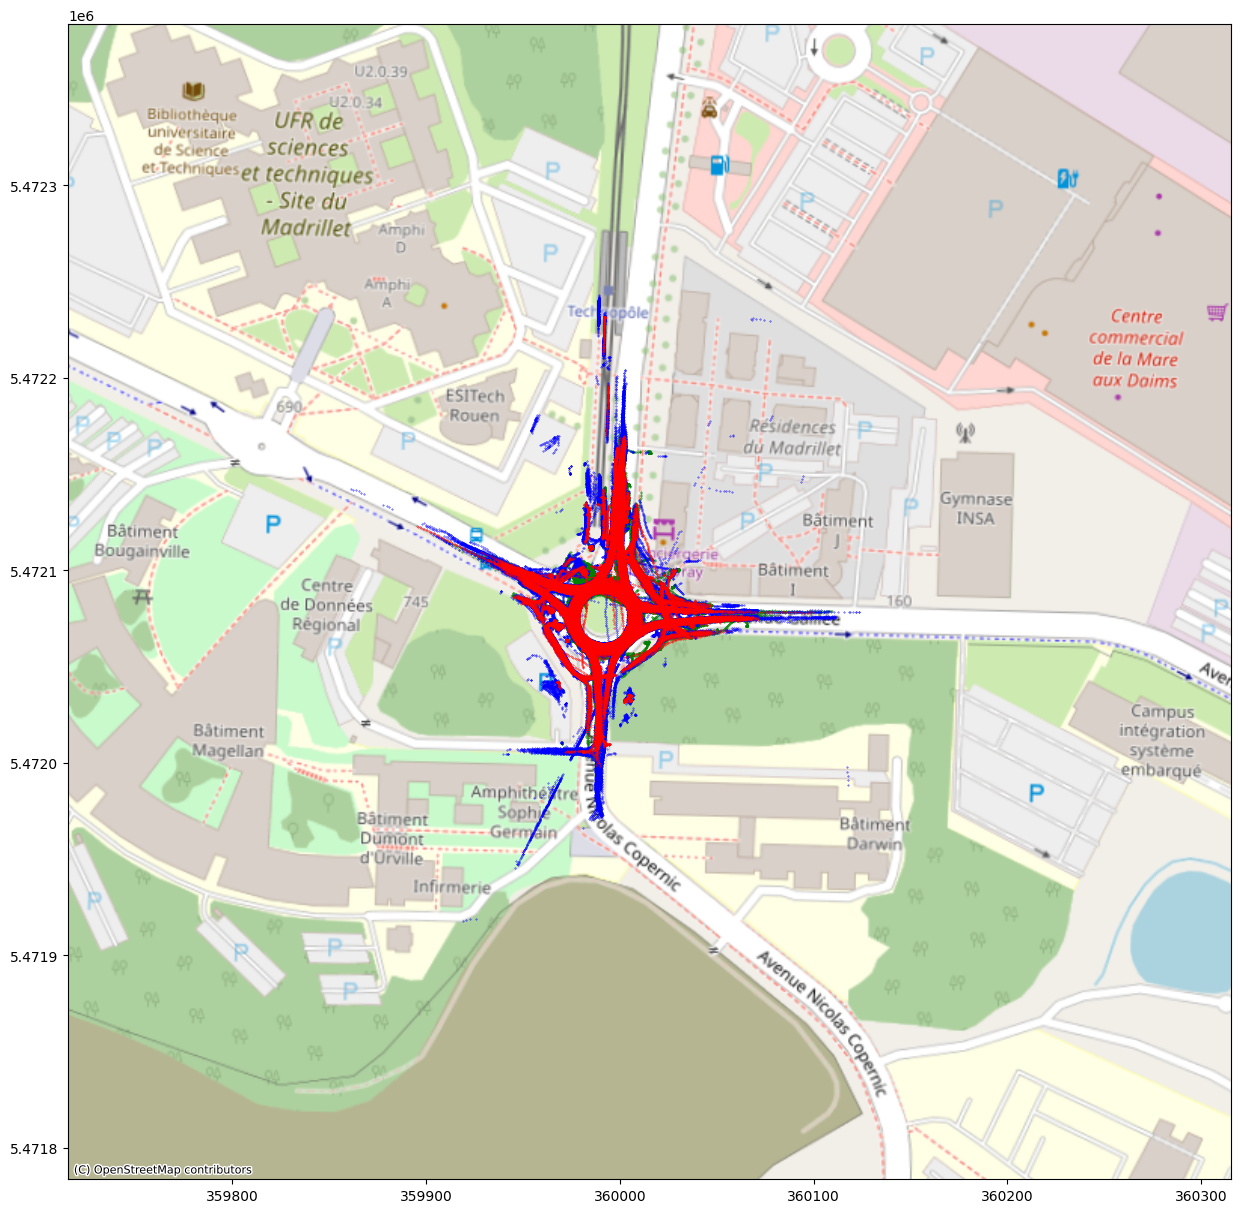

In [35]:
fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

# Filter data which is not on the selected road 

In [36]:
x, y = net.convertLonLat2XY(lon,lat)
rot_v_df = dg.rot_data(l_v_df,head)
rot_low_df = dg.rot_data(l_low_df,head)
rot_up_df = dg.rot_data(l_up_df,head)

v_rx = rot_v_df.loc[:,'rot_x']+x
v_ry = rot_v_df.loc[:,'rot_y']+y
# radius = 0.5
# edges = net.getNeighboringEdges(v_rx.iloc[0], v_ry.iloc[0], radius)
# # pick the closest edge
# if len(edges) > 0:
#     distancesAndEdges = sorted([(dist, edge) for edge, dist in edges], key=lambda x:x[0])
#     dist, closestEdge = distancesAndEdges[0]
    
# edges,dist,closestEdge.getID() , net.getEdge('60546306#1').getType()
row,_ = rot_v_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_v_df['edge'] = edge_list


v_rx = rot_low_df.loc[:,'rot_x']+x
v_ry = rot_low_df.loc[:,'rot_y']+y
row,_ = rot_low_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_low_df['edge'] = edge_list


v_rx = rot_up_df.loc[:,'rot_x']+x
v_ry = rot_up_df.loc[:,'rot_y']+y
row,_ = rot_up_df.shape
edge_list = []
for i in range(row):
   dist, edge = dg.on_road(v_rx.iloc[i],v_ry.iloc[i],net,1.5)
   if edge is not None:
      # print(edge)
      edge_list.append(edge.getID())
   else:
      edge_list.append(edge)
rot_up_df['edge'] = edge_list

In [37]:
rot_v_df = rot_v_df[rot_v_df['edge'].notnull()]
rot_low_df = rot_low_df[rot_low_df['edge'].notnull()]
rot_up_df = rot_up_df[rot_up_df['edge'].notnull()]

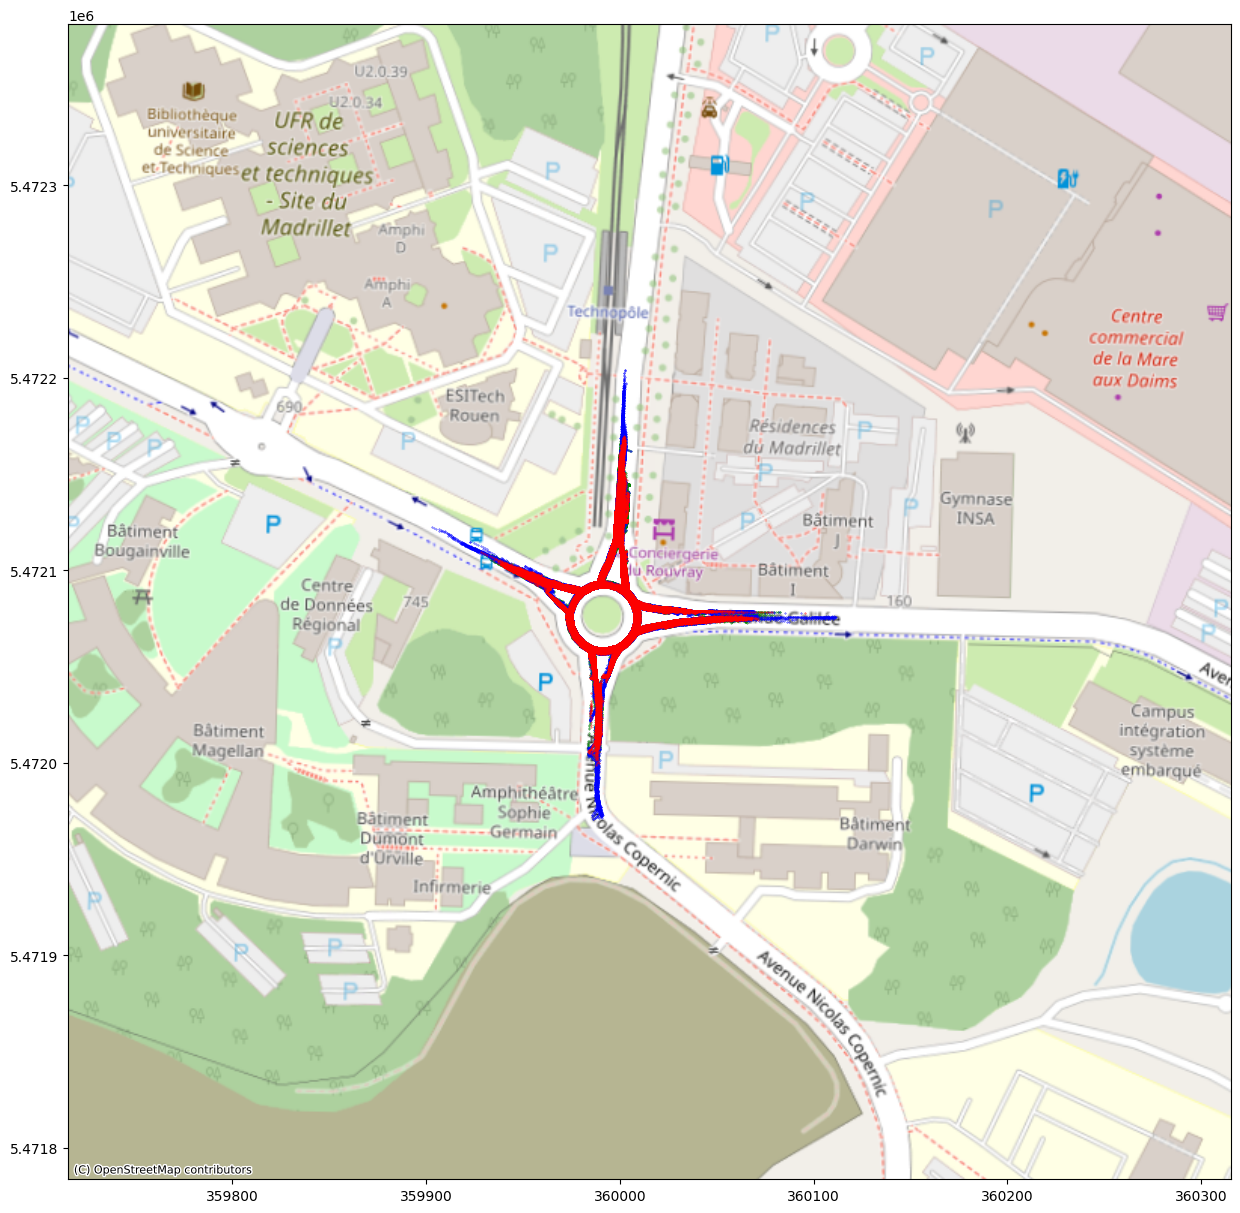

In [38]:
x, y = p(lon,lat)
v_rx = rot_v_df.loc[:,"rot_x"]+x
v_ry = rot_v_df.loc[:,"rot_y"]+y

low_rx = rot_low_df.loc[:,"rot_x"]+x
low_ry = rot_low_df.loc[:,"rot_y"]+y

up_rx = rot_up_df.loc[:,"rot_x"]+x
up_ry = rot_up_df.loc[:,"rot_y"]+y

fig,ax = plt.subplots(figsize=(15,15))
ax.scatter(up_rx,up_ry,s=0.1,c='g')
ax.scatter(low_rx,low_ry,s=0.1,c='b')
ax.scatter(v_rx,v_ry,s=0.1,c='r')
ax.set_xlim([x-300,x+300])
ax.set_ylim([y-300,y+300])

cx.add_basemap(
    ax,
    crs= p.crs,
    source=cx.providers.OpenStreetMap.Mapnik
)

# Save new training dataset with a fixed squence length

In [66]:
# interpolation for incomplete squences.
c_sq_df = dg.data_padding(rot_v_df,pad_method='linear',period_start=0,period_stop=-1)

In [67]:
# check if there are null values
c_sq_df[c_sq_df.isnull().any(axis=1)],c_sq_df.shape

(Empty DataFrame
 Columns: [Id, timestamp, positionX, positionY, positionZ, sizeX, sizeY, sizeZ, VelX, VelY, VelZ, Vel, Class, rot_x, rot_y, edge, ts]
 Index: [],
 (1765838, 17))

In [68]:
c_sq_df = c_sq_df.dropna(how='all')
c_sq_df.shape

(1765838, 17)

In [69]:
# add departure and destination 
df1 = c_sq_df.copy()
v_list = []
for k,v in c_sq_df.groupby(by=['Id']):
    v['departure'] = np.repeat(v.iloc[0,15],len(v))
    v['destination'] =  np.repeat(v.iloc[-1,15],len(v))
    v_list.append(v.copy())
new_c_sq_df = pd.concat(v_list)

In [70]:
new_c_sq_df.head(2)

,Id,timestamp,positionX,positionY,positionZ,sizeX,sizeY,sizeZ,VelX,VelY,VelZ,Vel,Class,rot_x,rot_y,edge,ts,departure,destination
0,549,1607521072912.0,-26.654327,-23.307135,-2.044877,1.128453,0.647314,0.30505,2.570297,8.248537,1.383134,31.499044,VEHICLE,-18.947553,29.910966,47254346#0,0,47254346#0,206566224#3
1,549,1607521073011.5,-26.416221,-22.149726,-1.8976,1.128453,0.647314,0.30505,2.557548,8.850294,1.408834,33.557258,VEHICLE,-19.047563,28.733559,47254346#0,1,47254346#0,206566224#3


In [71]:
new_c_sq_df.shape

(1765838, 19)

In [72]:
# stride 5s
rolling_window_df_1 = dg.rolling_window(new_c_sq_df.copy(),stride=50)
rolling_window_df_1.shape

(1540355, 20)

In [73]:
# stride 1s
rolling_window_df_2 = dg.rolling_window(new_c_sq_df.copy(),stride=10)
rolling_window_df_2.shape

(6960950, 20)

In [74]:
from datetime import datetime
now = datetime.now()
time = now.strftime("%Y%m%d_%H:%M:%S")

new_c_sq_df.to_csv('./dataset1/training/training_0_999_'+time+'.csv',index=False)
rolling_window_df_1.to_csv('./dataset1/training/training_0_999_r1_'+time+'.csv',index=False)
rolling_window_df_2.to_csv('./dataset1/training/training_0_999_r2_'+time+'.csv',index=False)

In [87]:
df = pd.read_csv('/home/ctm/Documents/ML/MLTest/symaps_data_analyze/preprocess/dataset1/training/training_0_999_20260210_16:50:35.csv')

In [88]:
df.shape

(1765838, 19)

In [89]:
# stride 5s
rolling_window_df_1 = dg.rolling_window(df.copy(),stride=50)

In [90]:
# stride 1s
rolling_window_df_2 = dg.rolling_window(df.copy(),stride=10)
rolling_window_df_1.shape,rolling_window_df_2.shape

((1399300, 20), (5158500, 20))

In [91]:
rolling_window_df_1.to_csv('/home/ctm/Documents/ML/MLTest/symaps_data_analyze/preprocess/dataset1/training/training_0_999_r1_20260210_16:50:35.csv',index=False)
rolling_window_df_2.to_csv('/home/ctm/Documents/ML/MLTest/symaps_data_analyze/preprocess/dataset1/training/training_0_999_r2_20260210_16:50:35.csv',index=False)